In [4]:
# %% [1] Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, precision_score, recall_score, f1_score)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
print ("All libraries import succesfully ")


All libraries import succesfully 


In [5]:
# %% [2] Load data + basic info
df = pd.read_csv(r"C:\Users\admin\Downloads\winequality-red (3).csv")  # change sep=',' if your file is comma-separated

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

Shape: (1599, 12)

Head:
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8      

In [6]:
# %% [3] Clean data — nulls + IQR outlier removal
print("Rows before cleaning:", df.shape[0])

# Handle nulls
df = df.dropna()
print("Rows after dropping nulls:", df.shape[0])

# IQR outlier removal (on all feature columns except target 'quality')
feature_cols = df.columns.drop('quality')

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Rows after IQR outlier removal:", df.shape[0])
df.reset_index(drop=True, inplace=True)


Rows before cleaning: 1599
Rows after dropping nulls: 1599
Rows after IQR outlier removal: 1135


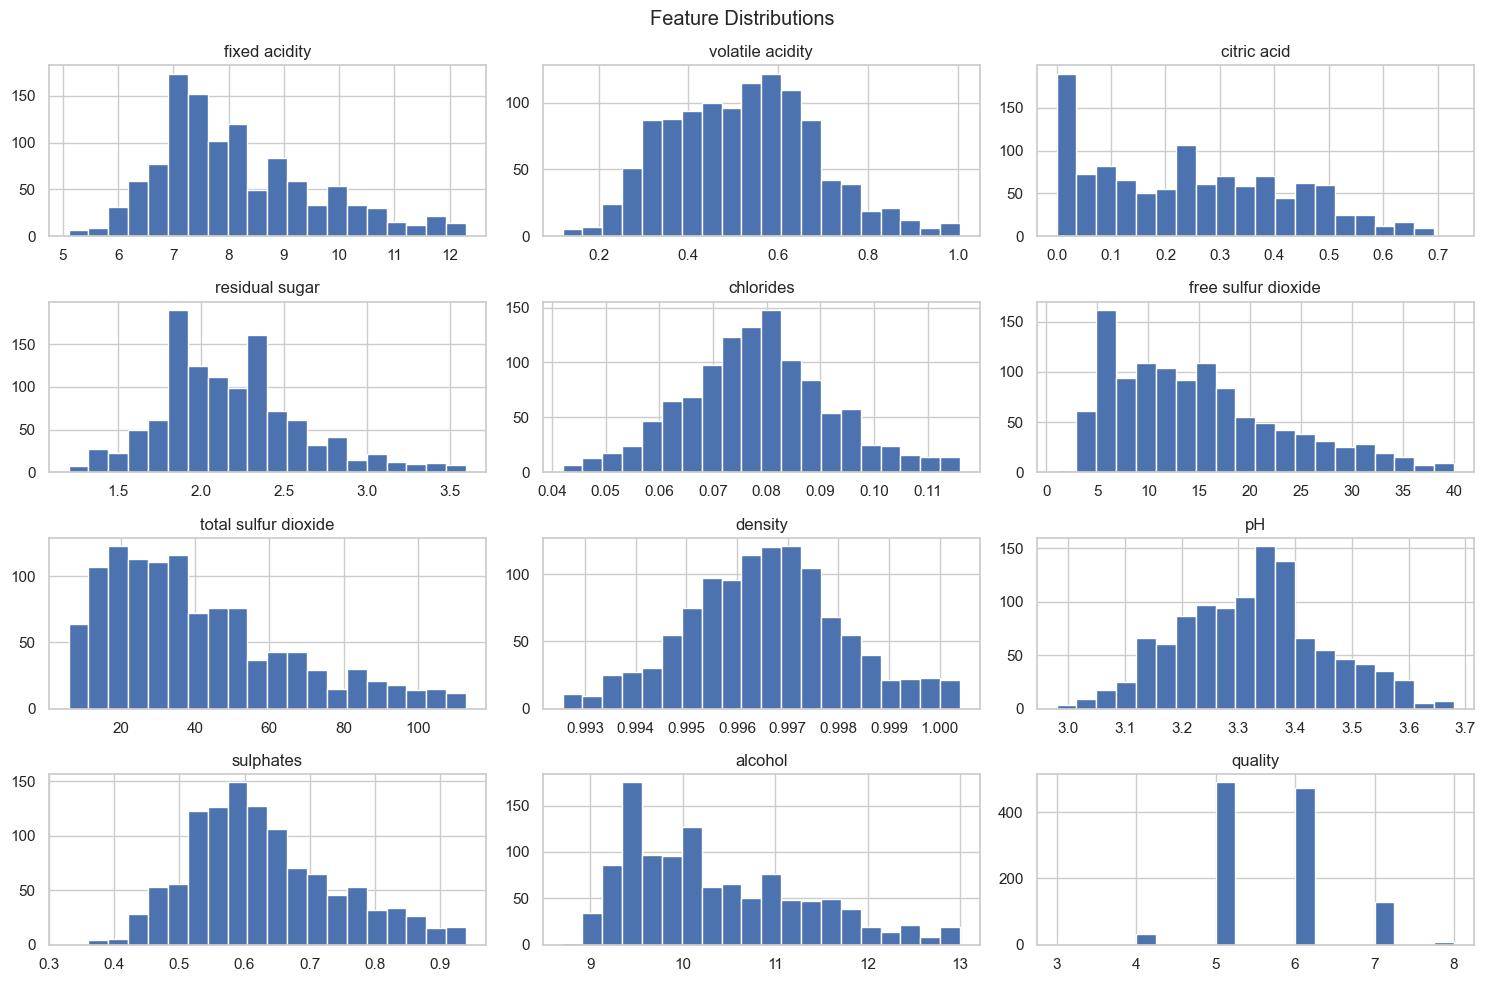

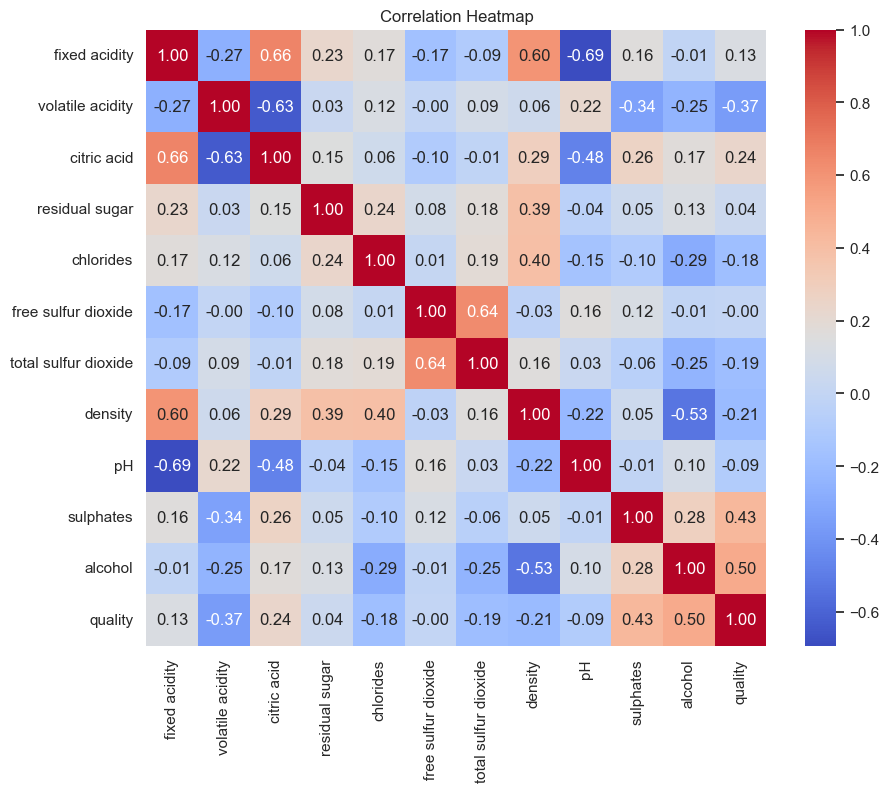

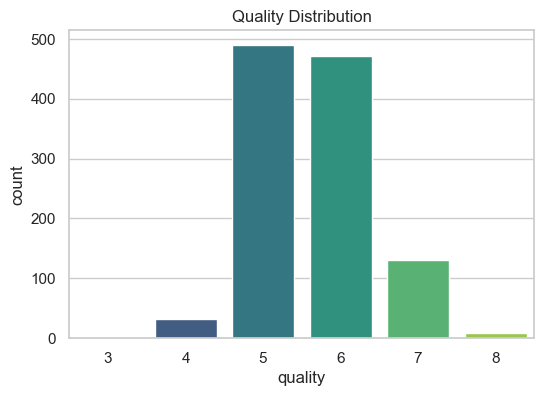

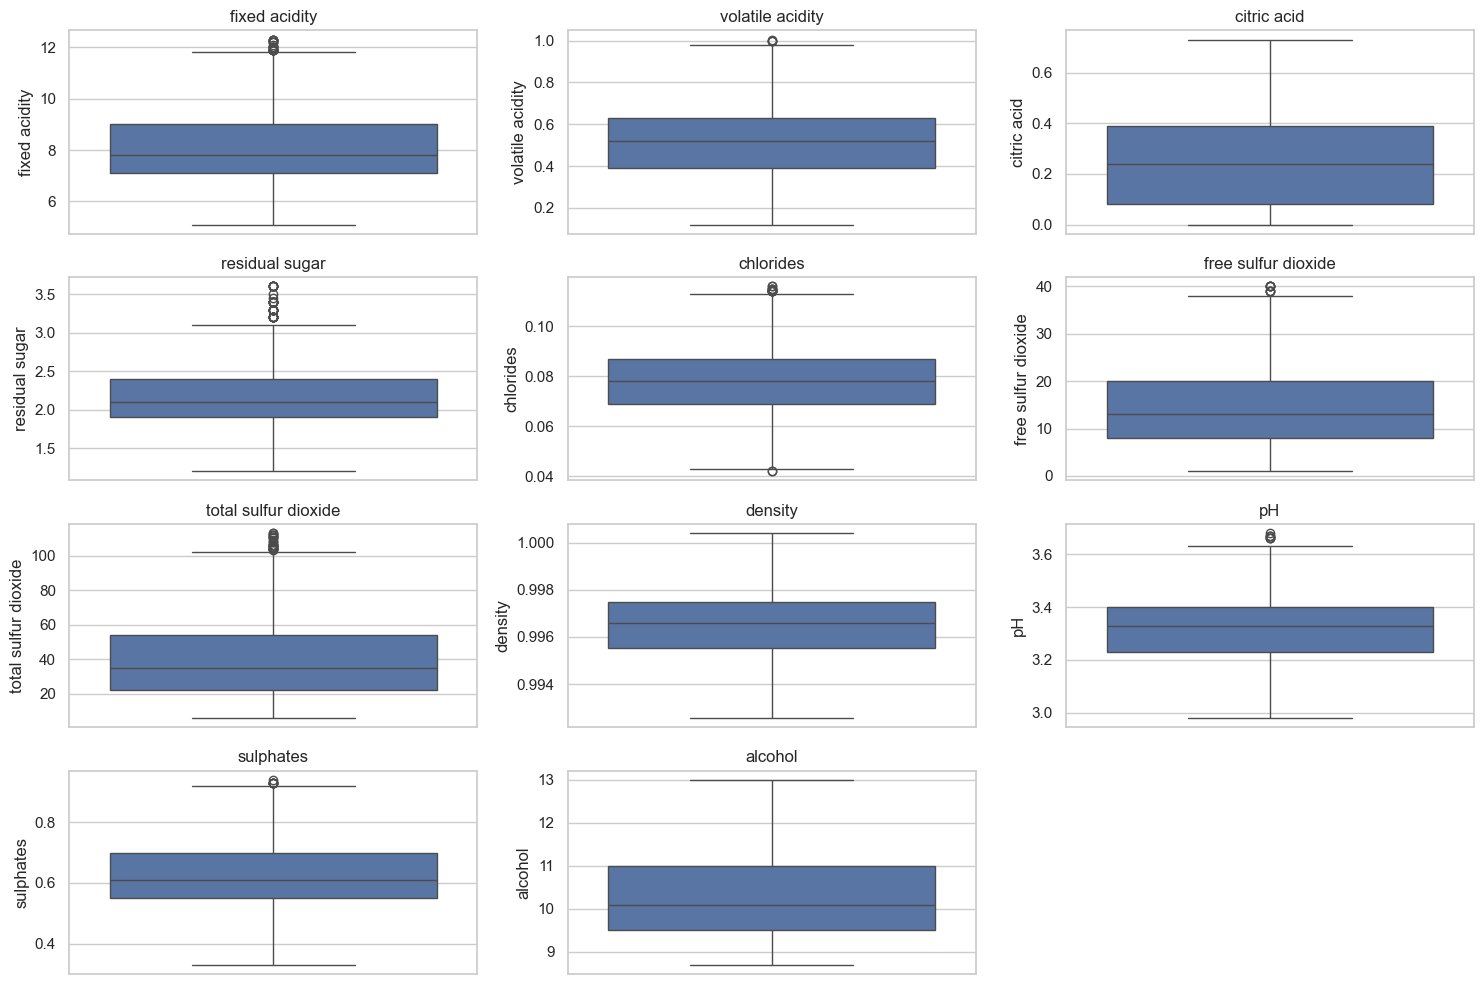

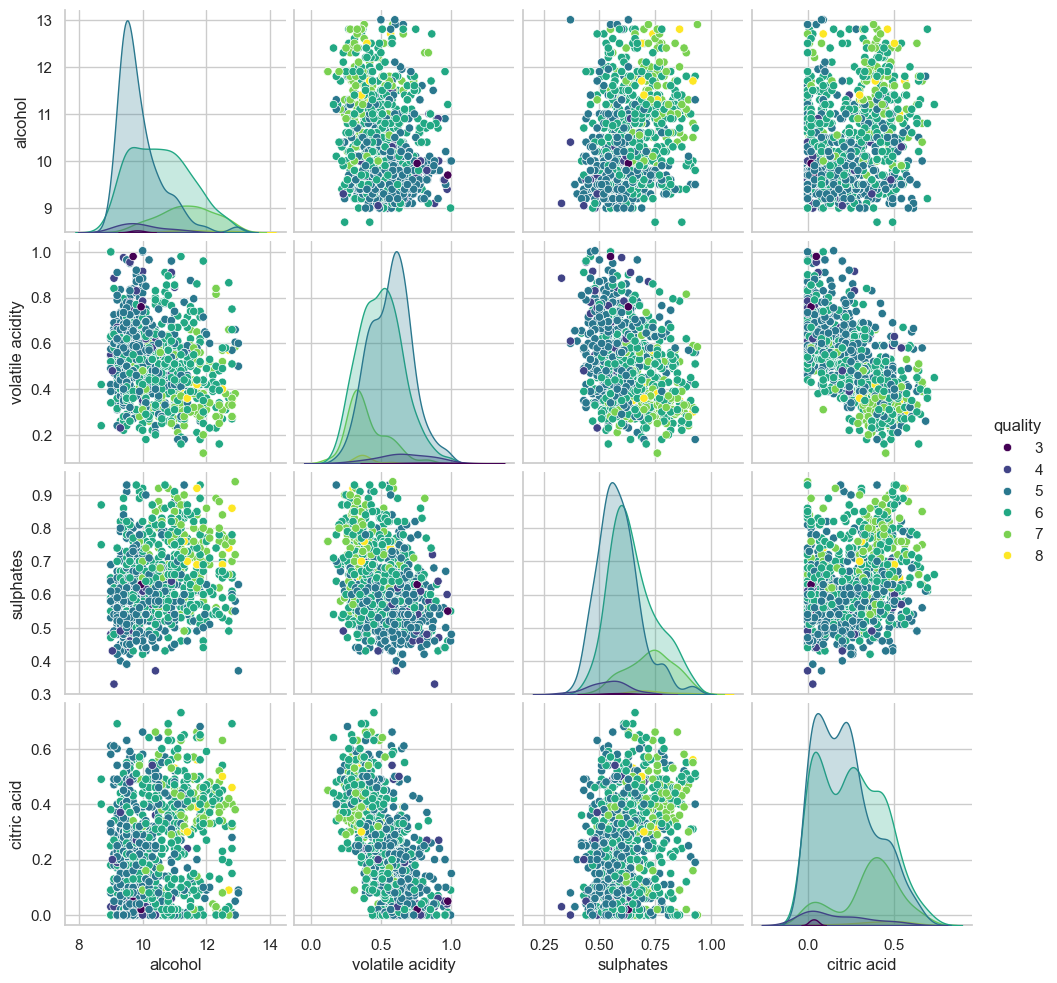

In [7]:
# %% [4] Visualize everything
df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='quality', data=df, palette="viridis")
plt.title("Quality Distribution")
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

sns.pairplot(df, vars=['alcohol', 'volatile acidity', 'sulphates', 'citric acid'], hue='quality', palette='viridis')
plt.show()


In [8]:
# %% [5] Train-test split + feature scaling
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape, "X_test:", X_test.shape)


X_train: (908, 11) X_test: (227, 11)


In [13]:

# %% [6.0] Initialize storage (run once before training models)
trained_models = {}
results = {}

In [11]:
# %% [6.1] Logistic Regression - train
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [12]:
trained_models["Logistic Regression"] = model
print("Logistic Regression trained.")

Logistic Regression trained.


In [14]:
# %% [6.2] KNN - train
model = KNeighborsClassifier()
model.fit(X_train, y_train)
trained_models["KNN"] = model
print("KNN trained.")

KNN trained.


In [15]:
# %% [6.3] SVM - train
model = SVC()
model.fit(X_train, y_train)
trained_models["SVM"] = model
print("SVM trained.")

SVM trained.


In [16]:
# %% [6.4] Decision Tree - train
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
trained_models["Decision Tree"] = model
print("Decision Tree trained.")

Decision Tree trained.


In [17]:
# %% [6.5] Random Forest - train
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
trained_models["Random Forest"] = model
print("Random Forest trained.")

Random Forest trained.


In [18]:
# %% [6.6] Gradient Boosting - train
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
trained_models["Gradient Boosting"] = model
print("Gradient Boosting trained.")

Gradient Boosting trained.


In [19]:
# %% [6.7] Naive Bayes - train
model = GaussianNB()
model.fit(X_train, y_train)
trained_models["Naive Bayes"] = model
print("Naive Bayes trained.")

Naive Bayes trained.



===== KNN =====
Accuracy: 0.5727 | Precision: 0.5516 | Recall: 0.5727 | F1: 0.5553
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.60      0.69      0.64        98
           6       0.56      0.59      0.57        94
           7       0.54      0.27      0.36        26
           8       0.00      0.00      0.00         2

    accuracy                           0.57       227
   macro avg       0.28      0.26      0.26       227
weighted avg       0.55      0.57      0.56       227



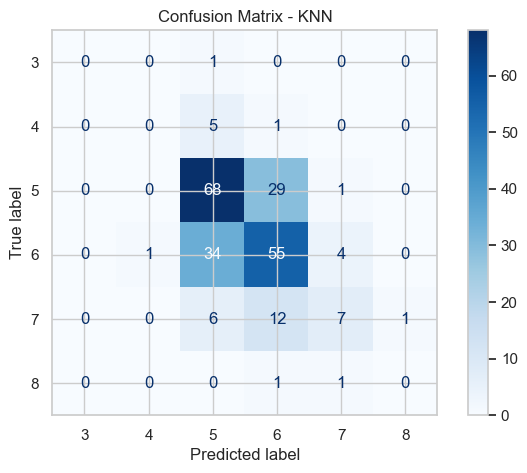


===== SVM =====
Accuracy: 0.6300 | Precision: 0.5979 | Recall: 0.6300 | F1: 0.6043
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.66      0.78      0.71        98
           6       0.60      0.65      0.63        94
           7       0.55      0.23      0.32        26
           8       0.00      0.00      0.00         2

    accuracy                           0.63       227
   macro avg       0.30      0.28      0.28       227
weighted avg       0.60      0.63      0.60       227



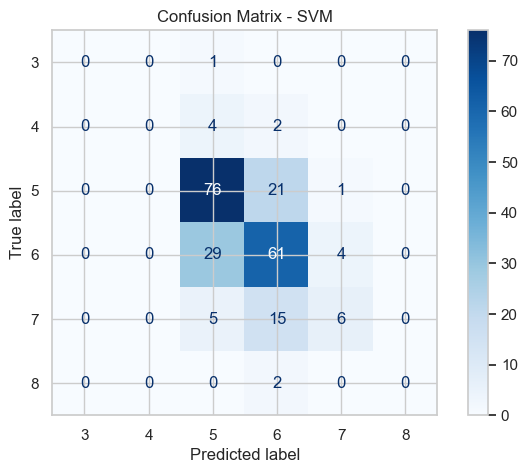


===== Decision Tree =====
Accuracy: 0.6079 | Precision: 0.6080 | Recall: 0.6079 | F1: 0.6041
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.62      0.72      0.67        98
           6       0.60      0.54      0.57        94
           7       0.71      0.58      0.64        26
           8       1.00      0.50      0.67         2

    accuracy                           0.61       227
   macro avg       0.49      0.39      0.42       227
weighted avg       0.61      0.61      0.60       227



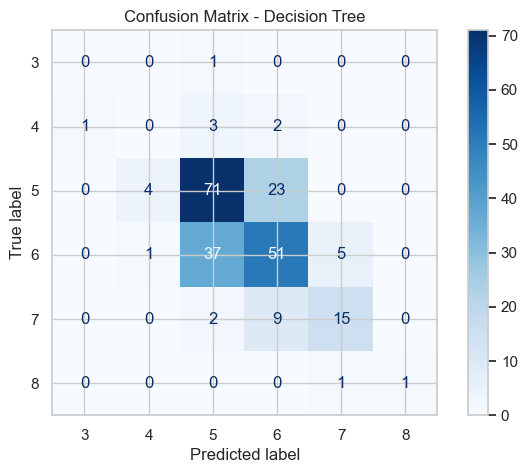


===== Random Forest =====
Accuracy: 0.6828 | Precision: 0.6691 | Recall: 0.6828 | F1: 0.6684
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.69      0.79      0.73        98
           6       0.66      0.69      0.67        94
           7       0.80      0.46      0.59        26
           8       1.00      0.50      0.67         2

    accuracy                           0.68       227
   macro avg       0.52      0.41      0.44       227
weighted avg       0.67      0.68      0.67       227



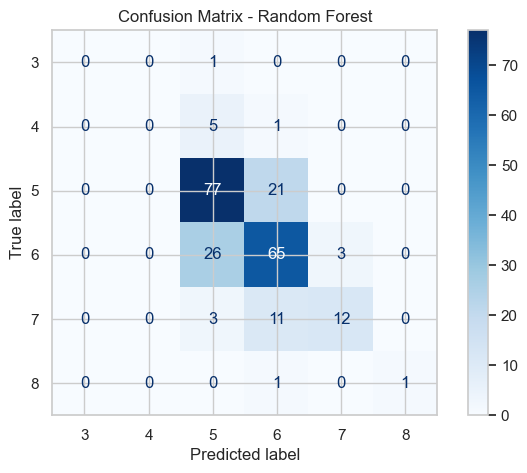


===== Gradient Boosting =====
Accuracy: 0.6300 | Precision: 0.6134 | Recall: 0.6300 | F1: 0.6199
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.68      0.74      0.71        98
           6       0.60      0.61      0.60        94
           7       0.60      0.46      0.52        26
           8       0.50      0.50      0.50         2

    accuracy                           0.63       227
   macro avg       0.40      0.39      0.39       227
weighted avg       0.61      0.63      0.62       227



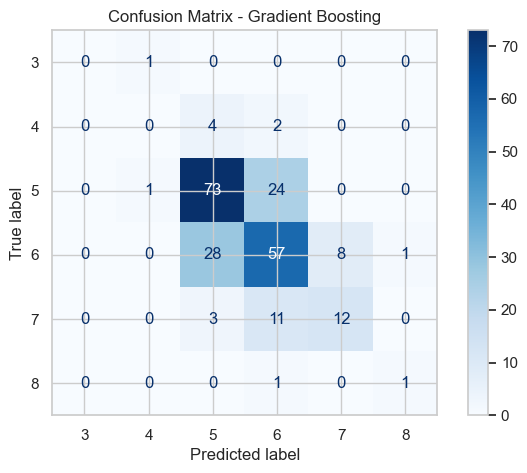


===== Naive Bayes =====
Accuracy: 0.5110 | Precision: 0.5084 | Recall: 0.5110 | F1: 0.5016
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.25      0.17      0.20         6
           5       0.59      0.71      0.65        98
           6       0.51      0.37      0.43        94
           7       0.30      0.38      0.34        26
           8       0.00      0.00      0.00         2

    accuracy                           0.51       227
   macro avg       0.28      0.27      0.27       227
weighted avg       0.51      0.51      0.50       227



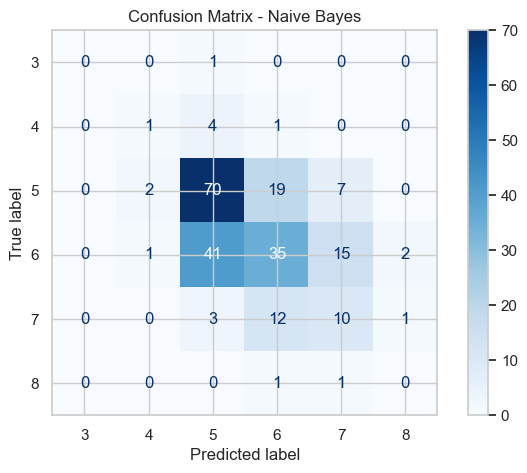

In [20]:
# %% [6.8] Evaluate all trained models — metrics + confusion matrix for each
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

    print(f"\n===== {name} =====")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Model Comparison:
                    Accuracy  Precision    Recall        F1
Random Forest      0.682819   0.669129  0.682819  0.668439
SVM                0.629956   0.597882  0.629956  0.604304
Gradient Boosting  0.629956   0.613395  0.629956  0.619912
Decision Tree      0.607930   0.607958  0.607930  0.604118
KNN                0.572687   0.551591  0.572687  0.555310
Naive Bayes        0.511013   0.508406  0.511013  0.501571


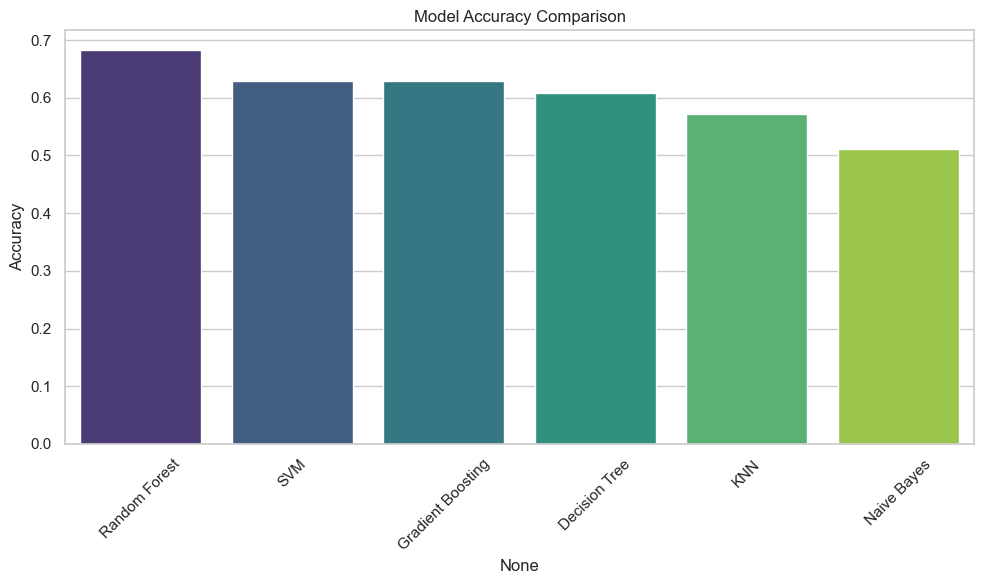


Best Model: Random Forest


In [21]:
# %% [6.9] Compare all models — accuracy bar chart + pick best model
results_df = pd.DataFrame(results).T.sort_values(by="Accuracy", ascending=False)
print("Model Comparison:\n", results_df)

plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y=results_df["Accuracy"], palette="viridis")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

best_model_name = results_df["Accuracy"].idxmax()
best_model = trained_models[best_model_name]
print("\nBest Model:", best_model_name)

Train Accuracy: 1.0000
Test Accuracy:  0.6828
Difference:     0.3172

Verdict: Overfitting: model performs much better on train data than test data.


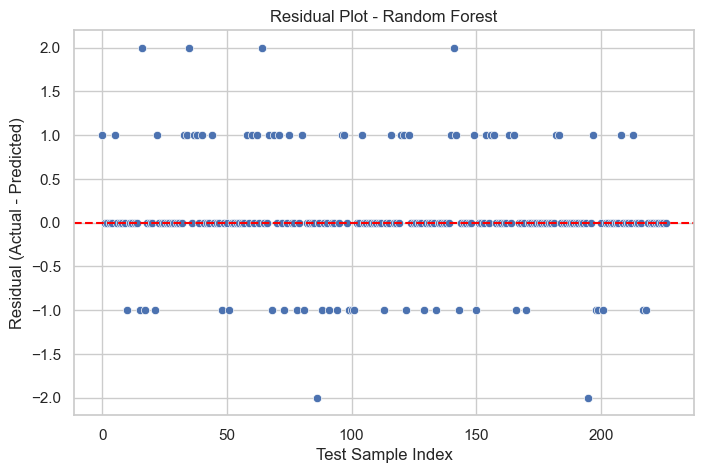

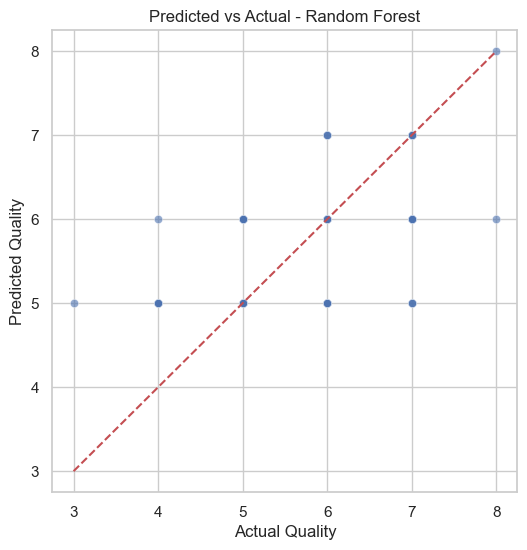

In [22]:
# %% [7] Evaluate best model — overfitting/underfitting
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Difference:     {abs(train_acc - test_acc):.4f}")

if train_acc - test_acc > 0.10:
    verdict = "Overfitting: model performs much better on train data than test data."
elif train_acc < 0.70 and test_acc < 0.70:
    verdict = "Underfitting: model performs poorly on both train and test data."
else:
    verdict = "Good fit: model generalizes reasonably well on unseen data."

print("\nVerdict:", verdict)

residuals = y_test.values - y_test_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=range(len(residuals)), y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Test Sample Index")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.show()

In [23]:
# %% [8] Test best model on 5 random test rows
sample_idx = np.random.choice(range(len(X_test)), 5, replace=False)
X_sample = X_test[sample_idx]
y_actual = y_test.values[sample_idx]
y_pred_sample = best_model.predict(X_sample)

error_pct = np.abs(y_actual - y_pred_sample) / np.where(y_actual == 0, 1, y_actual) * 100

sample_df = pd.DataFrame({
    "Actual": y_actual,
    "Predicted": y_pred_sample,
    "Error %": np.round(error_pct, 2)
})
print(sample_df)

   Actual  Predicted  Error %
0       6          7    16.67
1       5          5     0.00
2       6          5    16.67
3       5          5     0.00
4       6          6     0.00


In [ ]:
# %% [9] Manual input for all features and predict
print("Enter the following feature values:")
manual_values = []
for col in feature_cols:
    val = float(input(f"{col}: "))
    manual_values.append(val)

manual_df = pd.DataFrame([manual_values], columns=feature_cols)
manual_scaled = scaler.transform(manual_df)
manual_pred = best_model.predict(manual_scaled)

print("\nPredicted Wine Quality:", manual_pred[0])

Enter the following feature values:
